# Get SBO Terms
SBO ontology can be found at:
https://www.ebi.ac.uk/ols4/ontologies/sbo


In `...\analysis\model_preparation\001_standardization.ipynb` all models were annotated using SBOannotator (Leonidou, N., Fritze, E., Renz, A., & Dräger, A. (2023) SBOannotator: a Python Tool for the Automated Assignment of Systems Biology Ontology Terms. DOI: https://doi.org/10.1093/bioinformatics/btad437), found in this link:

<https://sbo-annotator-tuevis.cs.uni-tuebingen.de>

In [1]:
import os
import cobra
import pandas as pd

def get_reactions_per_sbo_cobra(model):
    SBO_MAP = {
        "SBO:0000176": "Biochemical reaction",
        "SBO:0000178": "Cleavage",
        "SBO:0000185": "Translocation reaction",
        "SBO:0000200": "Redox reaction",
        "SBO:0000211": "Removal of a chemical group",
        "SBO:0000214": "Methylation",
        "SBO:0000215": "Acetylation",
        "SBO:0000216": "Phosphorylation",
        "SBO:0000217": "Glycosylation",
        "SBO:0000233": "Hydroxylation",
        "SBO:0000376": "Hydrolysis",
        "SBO:0000377": "Isomerisation",
        "SBO:0000399": "Decarboxylation",
        "SBO:0000400": "Decarbonylation",
        "SBO:0000401": "Deamination",
        "SBO:0000402": "Transfer of a chemical group",
        "SBO:0000403": "Transamination",
        "SBO:0000627": "Exchange reaction",
        "SBO:0000628": "Demand reaction",
        "SBO:0000629": "Biomass production",
        "SBO:0000630": "ATP maintenance",
        "SBO:0000632": "Sink reaction",
        "SBO:0000657": "Active transport",
        "SBO:0000658": "Passive transport",
        "SBO:0000659": "Symporter-mediated transport",
        "SBO:0000660": "Antiporter-mediated transport",
        "SBO:0000695": "Ligation"
    }

    sbos_dict = {}
    for react in model.reactions:
        raw_sbo = react.annotation.get("sbo", "")
        sbo_id = str(raw_sbo).upper().strip() if raw_sbo else ""
        sbo_name = SBO_MAP.get(sbo_id, f"Other/Specific Process ({sbo_id})") if sbo_id and sbo_id != "SBO:0000000" else "No SBO Term / Unknown"
        sbos_dict[sbo_name] = sbos_dict.get(sbo_name, 0) + 1

    return sbos_dict

if __name__ == "__main__":
    folder_path = os.path.join(os.getcwd(), "..", "data", "models", "02_final_annotated")
    files_to_process = [f for f in os.listdir(folder_path) if f.endswith(".xml")]

    all_models_data = {}
    global_sbo_totals = {}

    for file in files_to_process:
        model_name = file.replace(".xml", "")
        print(f"Processing model: {model_name}")
        cobra_model = cobra.io.read_sbml_model(os.path.join(folder_path, file))
        counts = get_reactions_per_sbo_cobra(cobra_model)

        all_models_data[model_name] = counts
        for rxn_type, count in counts.items():
            global_sbo_totals[rxn_type] = global_sbo_totals.get(rxn_type, 0) + count

    sorted_columns = [item[0] for item in sorted(global_sbo_totals.items(), key=lambda x: x[1], reverse=True)]

    rows = [[model_name] + [counts.get(rxn_type, 0) for rxn_type in sorted_columns]
            for model_name, counts in all_models_data.items()]

    matrix_out = os.path.join(os.getcwd(), "..", "results", "tables", "SBO_Reaction_Matrix.csv")
    pd.DataFrame(rows, columns=["Model"] + sorted_columns).to_csv(matrix_out, index=False)
    print(f"[INFO] SBO matrix written to {matrix_out}")


Processing model: ecBSU1


'' is not a valid SBML 'SId'.


Set parameter Username


Set parameter LicenseID to value 2695449


--------------------------------------------


...

'' is not a valid SBML 'SId'.


Processing model: iBsu1209


Processing model: iYO844


Processing model: Submodel


[INFO] SBO matrix written to C:\Users\felip\Desktop\python\Bacillus_GEMs_Paper copy\analysis\notebooks\..\results\tables\SBO_Reaction_Matrix.csv


## Absolute reaction counts per SBO category
Stacked horizontal bars, one per model; the 9 lowest-count categories are dropped to keep the
plot readable.

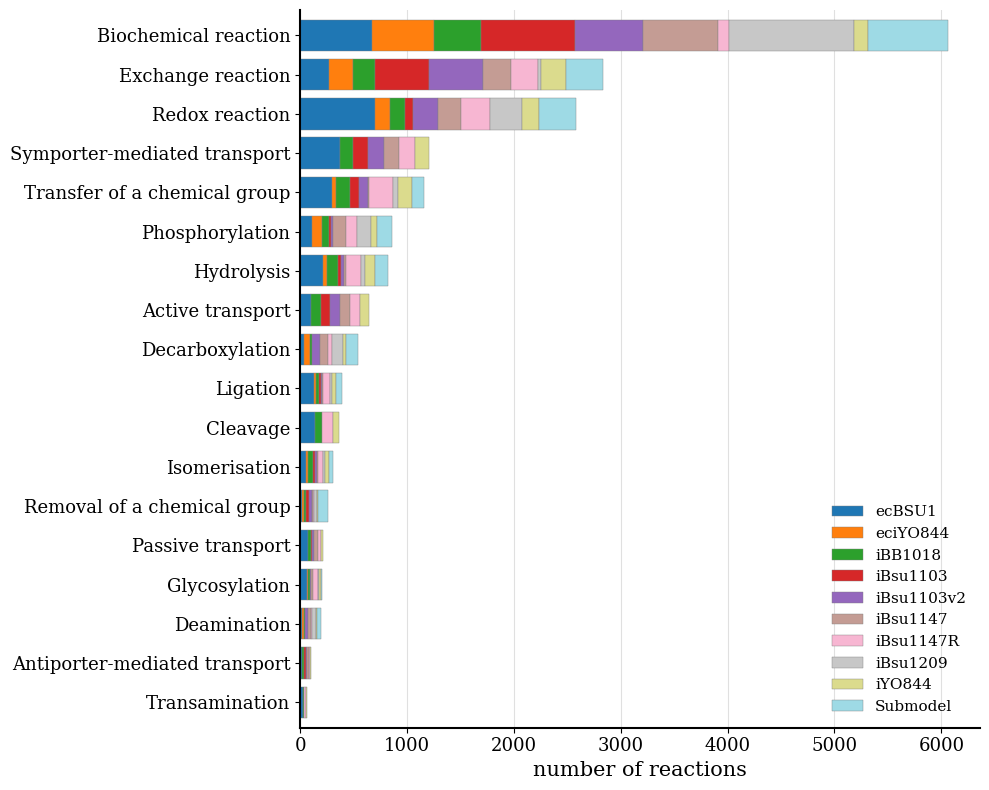

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

matrix_path = r"../results/tables/SBO_Reaction_Matrix.csv"
df = pd.read_csv(matrix_path).set_index("Model")

if "No SBO Term / Unknown" in df.columns:
    df = df.drop(columns=["No SBO Term / Unknown"])

df_plot = df.T
df_plot["Total"] = df_plot.sum(axis=1)

# Sort ascending so the lowest categories are at the top of the DataFrame
df_plot = df_plot.sort_values(by="Total", ascending=True)

# Drop the 9 categories with the lowest reaction counts
df_plot = df_plot.iloc[9:]

# Remove the helper total column before plotting
df_plot = df_plot.drop(columns=["Total"])

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 8))

# Use the 'tab20' colormap palette to provide up to 20 distinct colors for the models
df_plot.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", edgecolor="grey", linewidth=0.3, width=0.8)


ax.set_xlabel("number of reactions", fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.grid(axis="x", linestyle="-", color="lightgrey", alpha=0.7)
ax.set_axisbelow(True)

ax.legend(loc="lower right", frameon=False, fontsize=11)

plt.tight_layout()

output_path = os.path.join(os.getcwd(), "..", "results", "figures")
output_img_path = os.path.join(output_path, "SBO_AbsDistribution.pdf")
plt.savefig(output_img_path, dpi=300, bbox_inches="tight")
plt.show()


## SBO category distribution, relative to each model's total reactions
Same data as a 0-100% stacked bar. Transport subtypes are merged into one "Transport" category,
and any category under 1.5% of all reactions is grouped into "Other reactions".

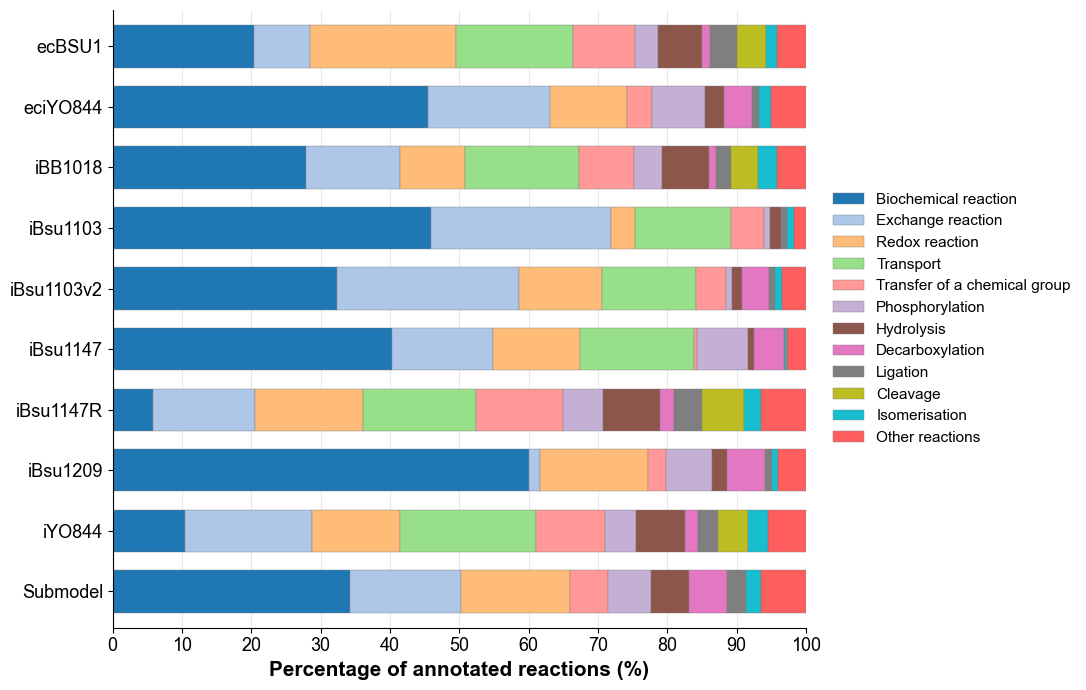

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

matrix_path = r"../results/tables/SBO_Reaction_Matrix.csv"
df = pd.read_csv(matrix_path).set_index("Model")

if "No SBO Term / Unknown" in df.columns:
    df = df.drop(columns=["No SBO Term / Unknown"])

transport_cols = [col for col in df.columns if "transport" in col.lower()]
if transport_cols:
    df["Transport"] = df[transport_cols].sum(axis=1)
    df = df.drop(columns=transport_cols)

global_totals = df.sum(axis=0)
grand_total = global_totals.sum()
threshold = grand_total * 0.015

minor_cols = global_totals[global_totals < threshold].index.tolist()

if minor_cols:
    df["Other reactions"] = df[minor_cols].sum(axis=1)
    df = df.drop(columns=minor_cols)

df_percentage = df.div(df.sum(axis=1), axis=0) * 100

sorted_columns = df_percentage.sum(axis=0).sort_values(ascending=False).index.tolist()

if "Other reactions" in sorted_columns:
    sorted_columns.remove("Other reactions")
    sorted_columns.append("Other reactions")

df_plot = df_percentage[sorted_columns]
df_plot = df_plot.iloc[::-1]

num_categories = len(df_plot.columns)
colors = plt.cm.tab20(np.linspace(0, 1, num_categories))

if "Other reactions" in df_plot.columns:
    other_idx = df_plot.columns.get_loc("Other reactions")
    colors[other_idx] = (1, 0.1, 0.1, 0.7)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
# Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
# the surrounding text is Arial, so one axis label ends up in two typefaces.
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
fig, ax = plt.subplots(figsize=(11, 7))

df_plot.plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="grey", linewidth=0.3, width=0.7)

ax.set_xlabel("Percentage of annotated reactions (%)", fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=13)
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.set_xticks(range(0, 101, 10))
ax.grid(axis="x", linestyle="-", color="lightgrey", alpha=0.5)
ax.set_axisbelow(True)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=11)

plt.tight_layout()

output_path = os.path.join(os.getcwd(), "..", "results", "figures")
output_img_path = os.path.join(output_path, "SBO_100Percent_Distribution_Flipped.pdf")
plt.savefig(output_img_path, dpi=800, bbox_inches="tight")
plt.show()
